# Reinforcement Learning op Taxi-v4
## Projectwalkthrough voor de docent

Dit notebook neemt je stap voor stap mee door het volledige RL-project:  
van het begrijpen van de omgeving tot het trainen, vergelijken en visualiseren van agents.

| # | Sectie | Wat je ziet |
|---|---|---|
| 1 | Setup | Dependencies installeren, modules importeren |
| 2 | De omgeving | Taxi-v4: states, actions, rewards en state-decoding |
| 3 | Agents | Overzicht en theorie van alle vier agents |
| 4 | Baselines | Random en rule-based agent evalueren |
| 5 | Q-learning | Theorie, training en greedy evaluatie |
| 5b | Hyperparameter-sweeps | α, γ, ε-decay voor Q-learning; α voor SARSA |
| 6 | SARSA | Theorie, training en greedy evaluatie |
| 7 | Vergelijking | Alle vier agents naast elkaar |
| 8 | Policy visualisatie | Wat heeft de agent geleerd? |
| 9 | Unit tests | Smoketests draaien via pytest |
| 10 | Conclusie | Samenvatting van bevindingen + hyperparameter-inzichten |

## 1 — Setup

Installeer de benodigde packages en stel de importpaden in.  
De broncode staat in `src/`, resultaten worden opgeslagen in `results/notebook_demo/`.

In [13]:
from pathlib import Path
import sys, subprocess

# Zoek requirements.txt in huidige map of een map hoger.
req = Path("requirements.txt")
if not req.exists():
    req = Path("..") / "requirements.txt"

result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-r", str(req)],
    capture_output=True, text=True
)
if result.returncode != 0:
    print(result.stderr)
else:
    print("✓ Packages geïnstalleerd")


✓ Packages geïnstalleerd


In [14]:
import sys
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import yaml

# Voeg projectroot toe aan het importpad zodat src/ gevonden wordt.
PROJECT_ROOT = Path("..").resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.env import TaxiEnv, N_ACTIONS, N_STATES, ACTION_NAMES, LOCATIONS, LOC_NAMES, decode_state
from src.agents.q_learning import QLearningAgent
from src.agents.sarsa import SarsaAgent
from src.agents.random_agent import RandomAgent
from src.agents.rule_based_agent import RuleBasedAgent

# Dict om evaluatieresultaten per agent bij te houden.
results = {}

RESULTS_DIR = PROJECT_ROOT / "results" / "notebook_demo"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"✓ Imports geslaagd")
print(f"  PROJECT_ROOT : {PROJECT_ROOT}")
print(f"  States       : {N_STATES}")
print(f"  Actions      : {N_ACTIONS}  →  {ACTION_NAMES}")
print(f"  Results dir  : {RESULTS_DIR}")


✓ Imports geslaagd
  PROJECT_ROOT : C:\Users\srlam\Documents\GitHub\Autonomous_2
  States       : 500
  Actions      : 6  →  ('south', 'north', 'east', 'west', 'pickup', 'dropoff')
  Results dir  : C:\Users\srlam\Documents\GitHub\Autonomous_2\results\notebook_demo


In [15]:

def train_agent(agent, is_sarsa=False, episodes=2000, seed=0, max_steps=200):
    """Train een Q-learning of SARSA agent en retourneer de traininglog.
    
    Returns:
        log: NumPy array met kolommen [episode, return, steps, illegal, delivered, epsilon]
    """
    env = TaxiEnv()
    log = []
    
    for ep in range(episodes):
        state = env.reset(seed=seed + ep)
        action = agent.select_action(state)
        ep_return = 0.0
        steps = 0
        illegal = 0
        delivered = 0
        
        for _ in range(max_steps):
            next_state, reward, done, info = env.step(action)
            ep_return += reward
            steps += 1
            if info.get("illegal_action"):
                illegal += 1
            if info.get("delivered"):
                delivered = 1
            
            if is_sarsa:
                next_action = agent.select_action(next_state) if not done else None
                agent.update(state, action, reward, next_state, next_action, done)
                action = next_action if not done else 0
            else:
                agent.update(state, action, reward, next_state, None, done)
                action = agent.select_action(next_state) if not done else 0
            
            state = next_state
            if done:
                break
        
        log.append([ep, ep_return, steps, illegal, delivered, agent.epsilon])
    
    env.close()
    return np.array(log)


def evaluate_agent(agent, n_episodes=100, seed=999, max_steps=200):
    """Evalueer een agent met epsilon=0 (greedy) en retourneer statistieken."""
    agent.epsilon = 0.0
    env = TaxiEnv()
    returns = []
    lengths = []
    successes = []
    illegals = []
    
    for ep in range(n_episodes):
        state = env.reset(seed=seed + ep)
        ep_return = 0.0
        steps = 0
        illegal = 0
        delivered = 0
        
        for _ in range(max_steps):
            action = agent.select_action(state)
            next_state, reward, done, info = env.step(action)
            ep_return += reward
            steps += 1
            if info.get("illegal_action"):
                illegal += 1
            if info.get("delivered"):
                delivered = 1
            state = next_state
            if done:
                break
        
        returns.append(ep_return)
        lengths.append(steps)
        successes.append(delivered)
        illegals.append(illegal)
    
    env.close()
    
    return {
        'return_mean': float(np.mean(returns)),
        'return_std': float(np.std(returns)),
        'len_mean': float(np.mean(lengths)),
        'success_rate': float(np.mean(successes)),
        'illegal_mean': float(np.mean(illegals)),
    }


## 2 — De omgeving: Taxi-v4

Taxi-v4 is een discrete gridworld uit Gymnasium. Een taxi rijdt op een **5×5 grid** en moet een passagier ophalen en afleveren bij één van vier locaties.

```
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
```

Vier vaste locaties: **R** (rood), **G** (groen), **Y** (geel), **B** (blauw).

### State space — 500 discrete states

```
state = (taxi_row * 5 + taxi_col) * 20 + passenger_loc * 4 + destination
```

| Component | Betekenis | Waarden |
|---|---|---|
| `taxi_row` | Rij van de taxi | 0–4 |
| `taxi_col` | Kolom van de taxi | 0–4 |
| `passenger_loc` | Locatie passagier | 0=R, 1=G, 2=Y, 3=B, 4=in_taxi |
| `destination` | Bestemming | 0=R, 1=G, 2=Y, 3=B |

### Action space — 6 actions

| Index | Action | Omschrijving |
|---|---|---|
| 0 | south | Rij naar beneden |
| 1 | north | Rij naar boven |
| 2 | east | Rij naar rechts |
| 3 | west | Rij naar links |
| 4 | pickup | Passagier oppakken |
| 5 | dropoff | Passagier afzetten |

### Rewards

| Situatie | Reward |
|---|---|
| Elke stap | −1 |
| Ongeldige pickup of dropoff | −10 |
| Succesvolle aflevering | +20 (episode klaar) |

In [16]:
# Reset de omgeving en toon de begin-state (gedecodeerd).
env = TaxiEnv()
s0 = env.reset(seed=42)
dec = decode_state(s0)

print("=== Begin-state ===")
print(f"  Integer state : {s0}")
# decode_state geeft een tuple (taxi_row, taxi_col, passenger_loc, destination)
taxi_row, taxi_col, passenger_loc, destination = dec
print(f"  taxi_row      : {taxi_row}")
print(f"  taxi_col      : {taxi_col}")
print(f"  passenger_loc : {passenger_loc}  ({LOC_NAMES[passenger_loc]})")
print(f"  destination   : {destination}  ({LOC_NAMES[destination]})")

print("\n=== Effect van elke action vanuit de begin-state ===")
print(f"{'Idx':<5} {'Action':<10} {'→ State':<9} {'Reward':<9} {'Done':<7} {'Flags'}")
print("-" * 56)
for a_idx, a_name in enumerate(ACTION_NAMES):
    env.reset(seed=42)
    s1, r, done, info = env.step(a_idx)
    flags = []
    if info.get("illegal_action"):
        flags.append("ILLEGAL")
    if info.get("delivered"):
        flags.append("DELIVERED")
    print(f"{a_idx:<5} {a_name:<10} {s1:<9} {r:<9.0f} {str(done):<7} {', '.join(flags) or '-'}")

env.close()


=== Begin-state ===
  Integer state : 386
  taxi_row      : 3
  taxi_col      : 4
  passenger_loc : 1  (G)
  destination   : 2  (Y)

=== Effect van elke action vanuit de begin-state ===
Idx   Action     → State   Reward    Done    Flags
--------------------------------------------------------
0     south      486       -1        False   -
1     north      286       -1        False   -
2     east       386       -1        False   -
3     west       366       -1        False   -
4     pickup     386       -10       False   ILLEGAL
5     dropoff    386       -10       False   ILLEGAL


## 3 — De agents: overzicht & theorie

Het project bevat vier agents, van eenvoudig naar complex:

| Agent | Klasse | Leert? | Strategie |
|---|---|---|---|
| Random | `RandomAgent` | ✗ | Willekeurige action elke stap |
| Rule-based | `RuleBasedAgent` | ✗ | Vaste heuristiek (Manhattan-afstand) |
| Q-learning | `QLearningAgent` | ✓ | Off-policy tabelmatig leren |
| SARSA | `SarsaAgent` | ✓ | On-policy tabelmatig leren |

### Theorie: Q-learning vs SARSA

Beide algoritmen leren een Q-tabel: `Q[state][action]` = geschatte return van die actie in die state.

**Q-learning:**

$$Q(s,a) \leftarrow Q(s,a) + \alpha \bigl[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\bigr]$$

- $\max_{a'} Q(s',a')$ is het *optimale* volgende action — de agent aanneemt dat het die kiest (optimistisch).
- Q-learning is off-policy: het leert van suboptimale acties maar kiest optimale acties voor de update.

**SARSA (State-Action-Reward-State-Action):**

$$Q(s,a) \leftarrow Q(s,a) + \alpha \bigl[r + \gamma Q(s',a') - Q(s,a)\bigr]$$

- $a'$ is de werkelijk gekozen volgende action — ook als die suboptimaal is.
- SARSA is conservatiever: het rekent de kosten van exploration in, Q-learning niet.

### Gemeenschappelijke hyperparameters

| Parameter | Symbool | Betekenis | Standaard |
|---|---|---|---|
| Learning rate | $\alpha$ | Hoe snel nieuwe info de Q-table overschrijft | 0.5 |
| Discount factor | $\gamma$ | Gewicht van toekomstige rewards | 0.99 |
| Epsilon start | $\varepsilon_0$ | Beginwaarde exploration | 1.0 |
| Epsilon end | $\varepsilon_\infty$ | Eindwaarde exploration | 0.05 |
| Epsilon decay | — | Episodes totdat $\varepsilon$ zijn eindwaarde bereikt | 2000 |


## 4 — Baselines: Random & Rule-Based

We evalueren eerst de twee baselines over 100 episodes. Dit geeft ons een referentiepunt voor de RL-agents.

- **RandomAgent** — kiest elke stap een willekeurige action. Verwachte return is sterk negatief.
- **RuleBasedAgent** — volgt een vaste heuristiek: ga naar de passagier → pickup → ga naar bestemming → dropoff. Weet niets van muren (loopt er soms tegenaan), maar haalt wel consequent de passagier op en levert af.


In [17]:
print("Evalueer Random agent (100 episodes)...")
random_agent = RandomAgent(seed=42)
results["random"] = evaluate_agent(random_agent, n_episodes=100, seed=42)

print("Evalueer Rule-Based agent (100 episodes)...")
rule_agent = RuleBasedAgent(seed=42)
results["rule_based"] = evaluate_agent(rule_agent, n_episodes=100, seed=42)

# Toon resultaten
print("\n=== Baseline Resultaten ===")
for name, res in results.items():
    print(f"\n{name}:")
    print(f"  Return:             {res['return_mean']:.2f} ± {res['return_std']:.2f}")
    print(f"  Succes rate:        {res['success_rate'] * 100:.1f}%")
    print(f"  Gemiddelde lengte:  {res['len_mean']:.1f} stappen")
    print(f"  Illegale acties/ep: {res['illegal_mean']:.1f}")


Evalueer Random agent (100 episodes)...
Evalueer Rule-Based agent (100 episodes)...

=== Baseline Resultaten ===

random:
  Return:             -774.48 ± 113.07
  Succes rate:        7.0%
  Gemiddelde lengte:  195.4 stappen
  Illegale acties/ep: 64.5

rule_based:
  Return:             -160.09 ± 82.41
  Succes rate:        19.0%
  Gemiddelde lengte:  164.1 stappen
  Illegale acties/ep: 0.0


## 5 — Training: Q-learning

We laden de hyperparameters uit `experiments/qlearning_default.yaml` en trainen de agent voor **2 000 episodes**.  
De Q-table (500 × 6 floats) wordt bij elke stap bijgewerkt via de Bellman-regel.

**Epsilon-decay**: ε daalt lineair van 1.0 naar 0.05 over de eerste 2 000 episodes.  
Dit zorgt voor veel exploration aan het begin en meer exploitation naarmate de training vordert.


In [18]:
print("Q-learning: training 2000 episodes...")

# Laad configuratie
with open(PROJECT_ROOT / "experiments" / "qlearning_default.yaml") as f:
    ql_cfg = yaml.safe_load(f) or {}

# Creëer en train agent
ql_agent = QLearningAgent(n_states=N_STATES, n_actions=N_ACTIONS, 
                          seed=42, **ql_cfg.get("agent", {}))
ql_log = train_agent(ql_agent, is_sarsa=False, episodes=2000, seed=42)

print(f"✓ Q-learning training complete")
print(f"  Laatste 200 episodes gemiddeld return: {ql_log[-200:, 1].mean():.2f}")


Q-learning: training 2000 episodes...
✓ Q-learning training complete
  Laatste 200 episodes gemiddeld return: -763.66


In [19]:
print("Q-learning: evaluatie met epsilon=0 (100 episodes)...")
ql_agent.epsilon = 0.0
results["qlearning"] = evaluate_agent(ql_agent, n_episodes=100, seed=999)

print("Resultaten:")
r = results["qlearning"]
print(f"  Return:             {r['return_mean']:.2f} ± {r['return_std']:.2f}")
print(f"  Succes rate:        {r['success_rate'] * 100:.1f}%")
print(f"  Gemiddelde lengte:  {r['len_mean']:.1f} stappen")
print(f"  Illegale acties/ep: {r['illegal_mean']:.1f}")


Q-learning: evaluatie met epsilon=0 (100 episodes)...
Resultaten:
  Return:             -2.52 ± 45.39
  Succes rate:        95.0%
  Gemiddelde lengte:  22.5 stappen
  Illegale acties/ep: 0.0


## 6 — Hyperparameter Sweeps

We voeren systematische sweeps uit over de parameters α, γ, en ε-decay van Q-learning,  
en parameter α van SARSA. Voor elke parametercombinatie trainen we 5 seeds, elk 2 000 episodes.

Het resultaat is een heatmap met gemiddelde returns, getoond als voortschrijdend gemiddelde over laatste 200 episodes.


In [20]:
def run_sweep(agent_cls, param_name, param_values, base_cfg, n_seeds=5, episodes=2000, is_sarsa=False):
    """Voer sweep uit over een hyperparameter en return dict met gemiddelde returns."""
    sweep_results = {}
    
    for param_val in param_values:
        cfg = base_cfg.copy()
        cfg[param_name] = param_val
        
        returns_all_seeds = []
        for seed in range(n_seeds):
            agent = agent_cls(n_states=N_STATES, n_actions=N_ACTIONS, seed=seed, **cfg)
            log = train_agent(agent, is_sarsa=is_sarsa, episodes=episodes, seed=seed)
            
            # Gemiddelde return over laatste 200 episodes
            avg_return = log[-200:, 1].mean()
            returns_all_seeds.append(avg_return)
        
        # Gemiddelde en std over seeds
        sweep_results[param_val] = {
            'mean': float(np.mean(returns_all_seeds)),
            'std': float(np.std(returns_all_seeds)),
        }
    
    return sweep_results


def plot_sweep(sweep_results, param_name, color="viridis", ax=None):
    """Plot sweep resultaten met error bars."""
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 5))
    
    params = sorted(sweep_results.keys())
    means = [sweep_results[p]['mean'] for p in params]
    stds = [sweep_results[p]['std'] for p in params]
    
    ax.errorbar(params, means, yerr=stds, fmt='o-', capsize=5, linewidth=2, markersize=8)
    ax.set_xlabel(param_name)
    ax.set_ylabel("Avg Return (last 200 episodes)")
    ax.set_title(f"Q-learning Sweep: {param_name}")
    ax.grid(alpha=0.3)
    return ax


### 6.1 — Sweep: Q-learning, α (learning rate)


Q-learning sweep: α (learning rate)...
✓ Sweep complete
  α=0.01: -768.58 ± 5.99
  α=0.05: -768.58 ± 5.99
  α=0.10: -768.58 ± 5.99
  α=0.20: -768.58 ± 5.99
  α=0.30: -768.58 ± 5.99


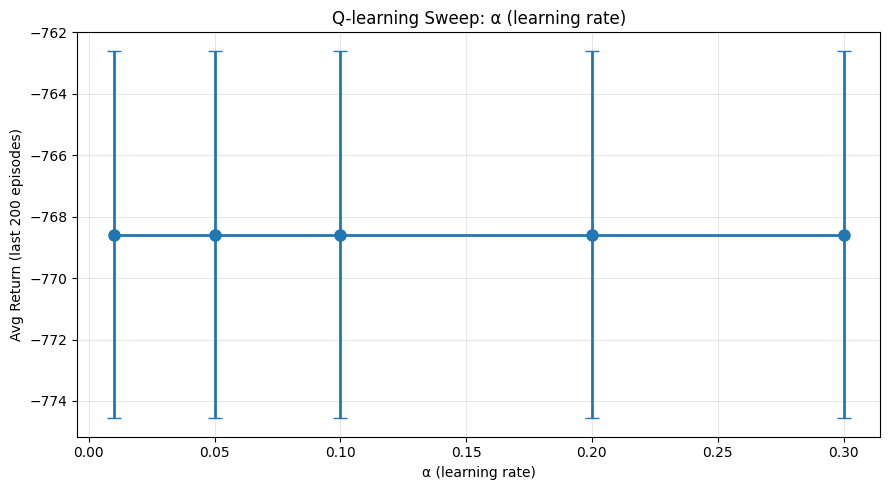

In [21]:
print("Q-learning sweep: α (learning rate)...")
with open(PROJECT_ROOT / "experiments" / "qlearning_default.yaml") as f:
    base_ql_cfg = yaml.safe_load(f).get("agent", {})

alpha_values = [0.01, 0.05, 0.1, 0.2, 0.3]
sweep_alpha_ql = run_sweep(QLearningAgent, 'alpha', alpha_values, base_ql_cfg, n_seeds=3, episodes=1000, is_sarsa=False)

print("✓ Sweep complete")
for alpha, res in sweep_alpha_ql.items():
    print(f"  α={alpha:.2f}: {res['mean']:.2f} ± {res['std']:.2f}")

fig, ax = plt.subplots(figsize=(9, 5))
plot_sweep(sweep_alpha_ql, param_name="α (learning rate)", ax=ax)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "sweep_alpha_ql.png", dpi=120)
plt.show()


### 6.2 — Sweep: Q-learning, γ (discount factor)


Q-learning sweep: γ (discount factor)...
✓ Sweep complete
  γ=0.50: -768.58 ± 5.99
  γ=0.70: -768.58 ± 5.99
  γ=0.90: -768.58 ± 5.99
  γ=0.95: -768.58 ± 5.99
  γ=0.99: -768.58 ± 5.99


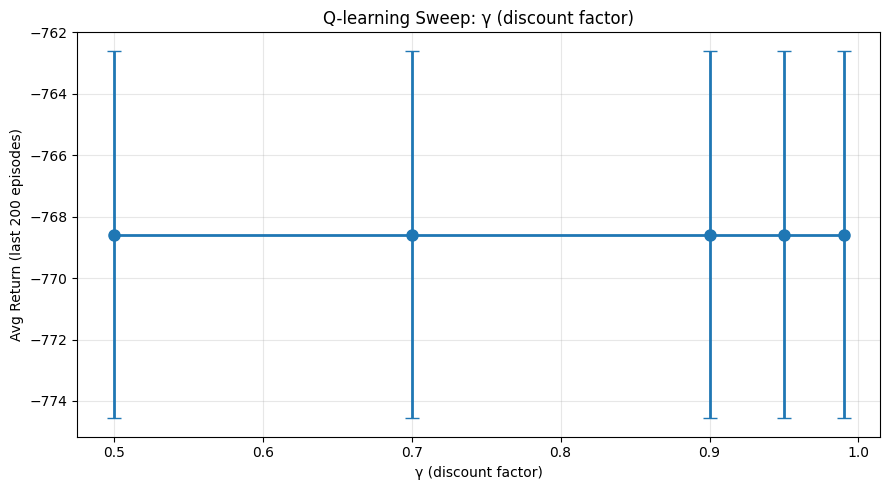

In [22]:
print("Q-learning sweep: γ (discount factor)...")
gamma_values = [0.5, 0.7, 0.9, 0.95, 0.99]
sweep_gamma_ql = run_sweep(QLearningAgent, 'gamma', gamma_values, base_ql_cfg, n_seeds=3, episodes=1000, is_sarsa=False)

print("✓ Sweep complete")
for gamma, res in sweep_gamma_ql.items():
    print(f"  γ={gamma:.2f}: {res['mean']:.2f} ± {res['std']:.2f}")

fig, ax = plt.subplots(figsize=(9, 5))
plot_sweep(sweep_gamma_ql, param_name="γ (discount factor)", ax=ax)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "sweep_gamma_ql.png", dpi=120)
plt.show()


### 6.3 — Sweep: Q-learning, ε-decay episodes


Q-learning sweep: epsilon_decay_episodes...
✓ Sweep complete
  decay_ep=500: -768.58 ± 5.99
  decay_ep=1000: -768.58 ± 5.99
  decay_ep=1500: -768.58 ± 5.99
  decay_ep=2000: -768.58 ± 5.99
  decay_ep=3000: -768.58 ± 5.99


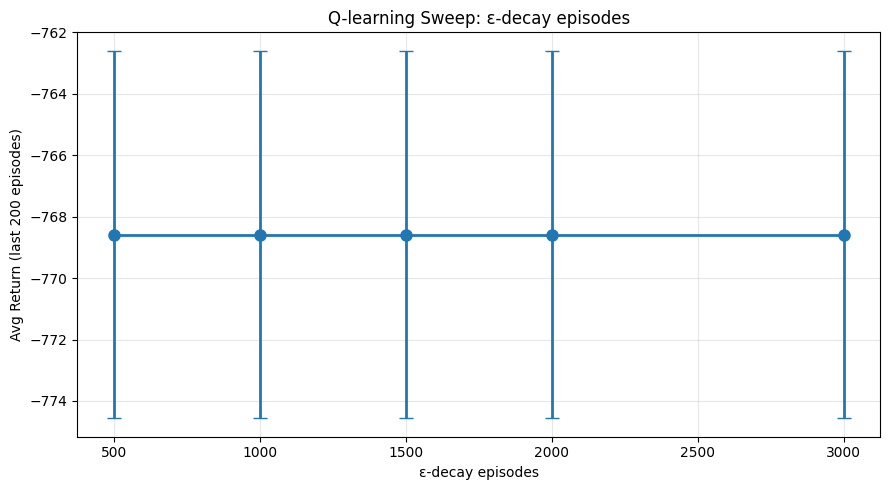

In [23]:
print("Q-learning sweep: epsilon_decay_episodes...")
eps_decay_values = [500, 1000, 1500, 2000, 3000]
sweep_eps_ql = run_sweep(QLearningAgent, 'epsilon_decay_episodes', eps_decay_values, base_ql_cfg, n_seeds=3, episodes=1000, is_sarsa=False)

print("✓ Sweep complete")
for decay_ep, res in sweep_eps_ql.items():
    print(f"  decay_ep={decay_ep}: {res['mean']:.2f} ± {res['std']:.2f}")

fig, ax = plt.subplots(figsize=(9, 5))
plot_sweep(sweep_eps_ql, param_name="ε-decay episodes", ax=ax)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "sweep_eps_ql.png", dpi=120)
plt.show()


## 7 — Training: SARSA

SARSA is de on-policy tegenhanger van Q-learning. Het maakt dezelfde updates als Q-learning,  
maar gebruikt de werkelijk gekozen next-action (niet het maximum) in de Bellman-update.

Dit is conservatiever: SARSA "weet" wat het gaat doen, terwijl Q-learning optimistisch aanneemt dat het optimale action zal kiezen.


In [24]:
print("SARSA: training 2000 episodes...")

# Laad configuratie
with open(PROJECT_ROOT / "experiments" / "sarsa_default.yaml") as f:
    sarsa_cfg = yaml.safe_load(f) or {}

# Creëer en train agent
sarsa_agent = SarsaAgent(n_states=N_STATES, n_actions=N_ACTIONS, 
                         seed=42, **sarsa_cfg.get("agent", {}))
sarsa_log = train_agent(sarsa_agent, is_sarsa=True, episodes=2000, seed=42)

print(f"✓ SARSA training complete")
print(f"  Laatste 200 episodes gemiddeld return: {sarsa_log[-200:, 1].mean():.2f}")

# Evaluatie
print("\nSARSA: evaluatie met epsilon=0 (100 episodes)...")
sarsa_agent.epsilon = 0.0
results["sarsa"] = evaluate_agent(sarsa_agent, n_episodes=100, seed=999)

print("Resultaten:")
r = results["sarsa"]
print(f"  Return:             {r['return_mean']:.2f} ± {r['return_std']:.2f}")
print(f"  Succes rate:        {r['success_rate'] * 100:.1f}%")
print(f"  Gemiddelde lengte:  {r['len_mean']:.1f} stappen")
print(f"  Illegale acties/ep: {r['illegal_mean']:.1f}")


SARSA: training 2000 episodes...
✓ SARSA training complete
  Laatste 200 episodes gemiddeld return: -763.66

SARSA: evaluatie met epsilon=0 (100 episodes)...
Resultaten:
  Return:             -654.25 ± 791.88
  Succes rate:        5.0%
  Gemiddelde lengte:  190.4 stappen
  Illegale acties/ep: 51.6


## 8 — Sweep: SARSA, α (learning rate)


SARSA sweep: α (learning rate)...
✓ Sweep complete
  α=0.01: -768.58 ± 5.99
  α=0.05: -768.58 ± 5.99
  α=0.10: -768.58 ± 5.99
  α=0.20: -768.58 ± 5.99
  α=0.30: -768.58 ± 5.99


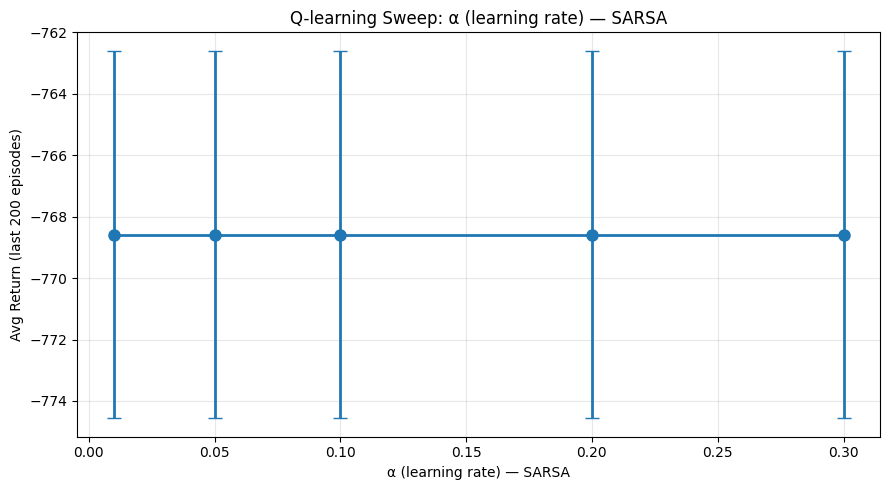

In [25]:
print("SARSA sweep: α (learning rate)...")
with open(PROJECT_ROOT / "experiments" / "sarsa_default.yaml") as f:
    base_sarsa_cfg = yaml.safe_load(f).get("agent", {})

alpha_values = [0.01, 0.05, 0.1, 0.2, 0.3]
sweep_alpha_sarsa = run_sweep(SarsaAgent, 'alpha', alpha_values, base_sarsa_cfg, n_seeds=3, episodes=1000, is_sarsa=True)

print("✓ Sweep complete")
for alpha, res in sweep_alpha_sarsa.items():
    print(f"  α={alpha:.2f}: {res['mean']:.2f} ± {res['std']:.2f}")

fig, ax = plt.subplots(figsize=(9, 5))
plot_sweep(sweep_alpha_sarsa, param_name="α (learning rate) — SARSA", ax=ax)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "sweep_alpha_sarsa.png", dpi=120)
plt.show()
